# Previsão de Demanda de Rede Farmacêutica

## Índice da Análise

1. Business Problem
    * Starting Context
        * Business Understanding
2. Starting Phase
    * Requirements
    * Libraries
3. Analysis Phase
    * Data Collection
    * Data Cleaning
        * Feature Extraction
    * Data Analysis
        * Descriptive Data Analysis
        * Hypotheses Mindmap
        * Exploratory Data Analysis
4. Model Phase
    * Feature Engineering
        * Data Preparation
        * Feature Selection
    * Model Building
        * Train-Test Splitting
        * Model Selection
            * Baseline Training
            * Cross Validation Training
            * Models Performance
    * Model Evaluation
        * Model Hyperparameter Fine Tuning
        * Metrics Interpretation
            * Business Metrics
            * Model Metrics
5. Deployment Phase
    * Visualization and Dashboard
        * Performance Assessment
        * Model Performance
            * Baseline vs Model Performance
            * Model Performance in Business
        * Business Performance Gain
    * API development
        * Prediction Class
        * API Handler
        * API Tester
    * Web App
        * Frontend

# Business Problem

## Contexto Inicial

"Uma empresa de distribuidora de medicamentos deseja melhorar suas previsões de demanda de produtos para otimizar seus estoques e reduzir custos operacionais. Atualmente, as previsões são feitas de forma manual e não têm sido eficazes, resultando tanto em excesso de estoque quanto em falta de produtos. Você foi convidado para desenvolver um modelo de previsão de demanda utilizando séries temporais."

##### Especificações do Projeto

- Meta
    - Desenvolver um modelo de previsão de demanda para os próximos 12 meses, com base nos dados históricos de vendas de um produto específico.

- Ferramentas
    - Deve-se utilizar técnicas de séries temporais para criar esse modelo, focando na escolha apropriada de métricas de erro e na análise crítica do desempenho do modelo em relação ao conjunto de dados de validação. 

- Etapas Esperadas
    - EDA - Exploração Inicial dos Dados: Realize uma extensa análise exploratória dos dados, identificando padrões
        - Além disso, devem-se considerar fatores como tendências, sazonalidade e possíveis anomalias.

    - Modelagem: Utilizar pelo menos 2 métodos de modelagem para prever a demanda futura. Recomendamos considerar:

        - Modelos tradicionais de séries temporais (como ARIMA, SARIMA, ou ETS, etc).

        - Modelos baseados em aprendizado de máquina (como LSTM, Prophet ou outros).

        - Modelos de séries temporais hierarquicas (top-down, botton-up, etc)

        - Validação Cruzada: Justificar porque foi escolhido tal método em vez de outro (levando em consideração as particularidades de séries temporais (como Time Series Split) )
            - Caso usar validação cruzada no fine tunning, justicar também.

    - Métricas de Avaliação do Modelo
    
        - Avaliar o desempenho do seu modelo utilizando as seguintes métricas de erro:

            - MAE (Mean Absolute Error)

            - MSE (Mean Squared Error)

            - RMSE (Root Mean Squared Error)

            - MAPE (Mean Absolute Percentage Error)

            - WMAPE (Weighted Mean Absolute Percentage Error)

            - Explicar qual métrica se considera mais adequada para este tipo de problema e por quê

            - Focar nas métricas de erro mas não exclua as outras

        - Ajuste de Hiperparâmetros: Descreva o processo de ajuste de hiperparâmetros, se aplicável e porque usou tal método em vez de outro.

        - Análise de Resíduos
            - Avaliar os resíduos do modelo 
            - Avaliar o cumprimento ou não dos pressupostos estatístico e seus respectivos p-values


Entrega final:

- Análise Exploratória dos Dados (EDA).
    - Qualidade da Análise Exploratória: Identificação adequada de padrões nas séries temporais (tendência, sazonalidade, etc.).

- Explicação detalhada dos modelos escolhidos e das etapas de validação.
    - Adequação do Modelo: Capacidade de escolher modelos apropriados para a tarefa.

- Discussão das métricas, principalmente de erros, resíduos e interpretação dos resultados.
    - Explicação das Métricas (principalmente de Erro): Clareza e precisão ao explicar as métricas utilizadas, e justificativa para a métrica escolhida como principal.

- Conclusões sobre a eficácia dos modelos.
    - Interpretação do Resultado: Capacidade de interpretar os resultados e oferecer insights úteis para o negócio.

- Código bem estruturado e extensamente comentado, pronto para ser executado.
    - Qualidade do Código: Organização, clareza, uso adequado de comentários e eficiência.

- Caso queira, sinta-se à vontade para propor novos insights ou métodos além do solicitado.
    - Profundidade Técnica: Demonstração de conhecimento avançado em séries temporais, modelos, métricas, e análise de resíduos.

Diferenciais Bônus:

- Se um dos modelos escolhidos for de série temporal hierárquica.

- Demonstrar profundidade no uso do WMAPE

- Consideração de variáveis exógenas coletadas de datasets públicos.

- Uso do mlflow

##### Entendimento do Negócio

É possível entender o problema de negócio fazendo apenas 4 perguntas, estas são:

* Qual a Motivação?
    - Qual o contexto?
* Qual a causa raiz do problema?
    - Porque fazer uma análise de vendas e não outra coisa?
* Quem é o dono do problema?
    - Quem precisa dessa solução? Quem vai nos cobrar?
* Qual o formato da solução de deploy?
    - Granularidade:
        - Qual o alcance esperado para se fazer essa análise?
        - Análise feita semanal, diária, mensal, por loja, por cidade etc
    - Tipo de Análise:
        - Será regressão, classificação, clustering, etc
    - Potenciais Métodos:
        - Podemos supor que vai ser usado qual algoritmo? random forest, regressão linear, KNN, etc
    - Formato de deploy:
        - Aplicação web, aplicação mobile, bot do Telegram, Docker, Heroku, AWS, etc

No nosso caso, as respostas para as perguntas acima são:

* Qual a motivação?
    - O Representante da empresa distribuidora de medicamentos requisitou uma análise de vendas para os próximos 12 meses.
* Qual a causa raiz do problema?
    - Melhor previsibilidade de demanda, gerando assim um melhor controle de estoque e redução de custos operacionais de logística.
    - Dificuldade em determinar o valor da demanda mensal
* Quem é o dono do problema?
    - O Representante da empresa distribuidora
* Qual o formato da solução de deploy?
    - Granularidade:
        - Previsão de demanda mensal
    - Tipo de Análise:
        - Predição de séries temporais
    - Potenciais Métodos:
        - Modelos como ARIMA, SARIMA, LSTM, Prophet, XGBoost
    - Formato de deploy:
        - Predição mensal (para o próximo mês) acessada via celular
            - Idealmente, o modelo pode ser refinado mês a mês, com a inclusão dos dados do mês corrente
            - A primeira entrega, no entanto, é a predição completa dos próximos 12 meses
        - Utilizar API do Telegram

# Starting Phase

Na fase inicial do projeto importamos as bibliotecas necessárias, fazemos as configurações iniciais do notebook e de algumas bibliotecas.

Com ela bem feita vamos ter tudo pronto para seguir a análise bem configurada e reprodutível para outras pessoas.

##### Requirements.txt

```
# Core data analysis and visualization
pandas>=2.0.0
numpy>=1.24.0
matplotlib>=3.7.0
seaborn>=0.12.0
scipy>=1.10.0
tabulate>=0.9.0
# NLP and text processing
inflection>=0.5.1
# Utility libraries
requests>=2.28.0
# ipython>=8.10.0 # Perhaps you already have it
# Machine Learning
scikit-learn>=1.2.0
xgboost>=1.7.0
lightgbm>=3.3.0
catboost>=1.1.0
boruta>=0.3.0
# Time Series Analysis
statsmodels>=0.13.0
prophet>=1.1.0
# Other utilities
python-dateutil>=2.8.0

```

## Libraries

In [1]:
try:
    # Fundamental Analytics libraries
    import pandas as pd
    import seaborn as sns
    import numpy as np
    from matplotlib import pyplot as plt
    from scipy import stats as sts
    # Toolbox libraries
    import time
    import math
    import pickle
    import random
    import requests
    import inflection #NLP
    import warnings
    from operator import itemgetter as pick
    from datetime import datetime, timedelta
    from tabulate import tabulate
    from IPython.display import Image
    from IPython.core.display import HTML
    import json
    # Feature Engineering
    from sklearn.preprocessing import RobustScaler, MinMaxScaler, LabelEncoder
    # Model libraries
    # Regressors, feature selection
    from boruta import BorutaPy
    import xgboost as xgblib
    from xgboost import XGBRegressor
    from lightgbm import LGBMRegressor
    from catboost import CatBoostRegressor
    from sklearn.ensemble import RandomForestRegressor
    # Statsmodels - Time Series
    from statsmodels.tsa.seasonal import seasonal_decompose # Decomposition
    from statsmodels.tsa.stattools import adfuller          # Stationarity
    from statsmodels.stats.diagnostic import acorr_ljungbox # Autocorrelation
    from statsmodels.tsa.statespace.sarimax import SARIMAX  # ARIMA and Seasonal ARIMA with Exogenous Variables
    # Time Series
    from prophet import Prophet                             # Prophet
    # Metrics
    from sklearn.metrics import mean_absolute_error, mean_squared_error, mean_absolute_percentage_error
    # Initial configurations
    warnings.filterwarnings('ignore')
    warnings.simplefilter(action = 'ignore', category = FutureWarning)
    xgblib.set_config(verbosity = 0)
    # Info about imports
    print("Import successful")
    
except Exception as e:
    print("Error while importing libraries: ", "/n", e)

Import successful


In [2]:
Start = datetime.now() 

## Notebook Settings

In [3]:
def notebook_settings():
    %matplotlib inline
    
    plt.style.use('bmh')
    plt.rcParams['figure.figsize'] = [30, 15]
    plt.rcParams['font.size'] = 24
    
    display(HTML('<style>.container { width:100% !important; }</style>'))
    #pd.options.display.max_columns = None
    #pd.options.display.max_rows = None
    #pd.set_option('display.expand_frame_repr', False)
    sns.set_theme()
    
notebook_settings()

##### Procedimento padrão dos projetos de Data Science

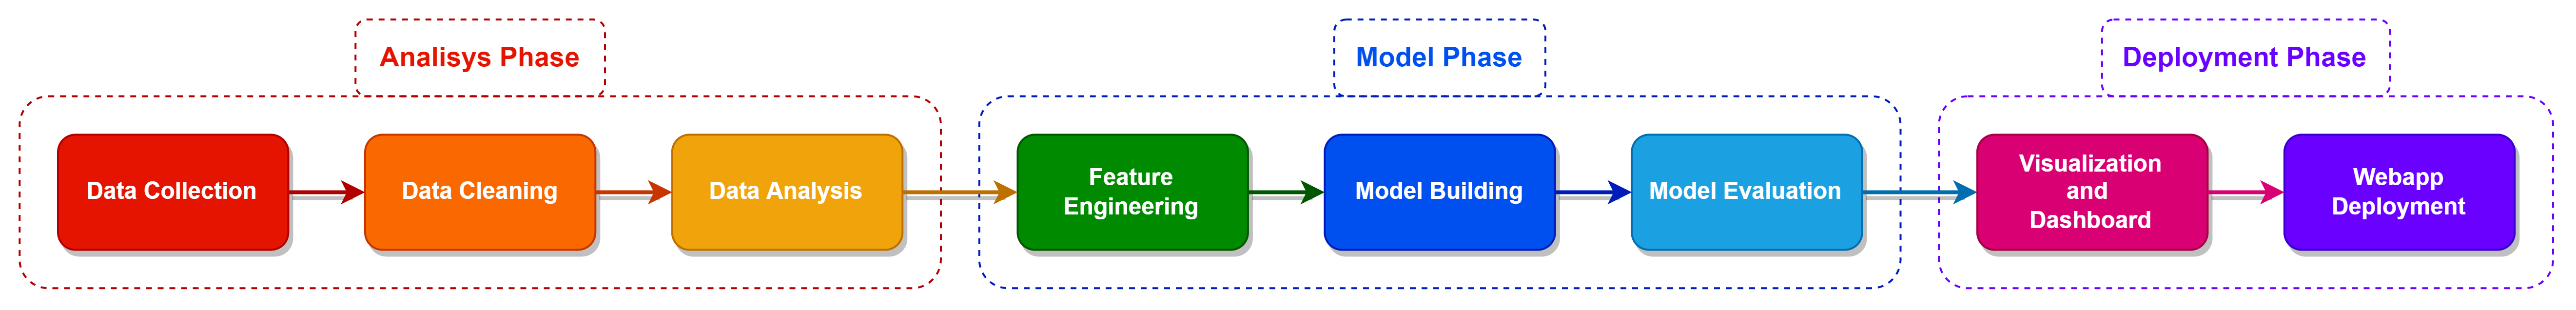

In [11]:
Image(filename='.\\Assets\\DS_sequence.png')

## Data Collection

In [13]:
# Carregamento do dataset
try:
    df_raw = pd.read_csv('.\df_case_1_-_500_linhas.csv')
    print("Dataset carregado com sucesso")
except Exception as e:
    print(f"Erro ao carregar: {e}")


Dataset carregado com sucesso


In [14]:
df_raw.head()

,CATEGORIA,PRODUTO,FORNECEDOR,COMPRADOR,CENTROS DE DISTRIBUICAO,DESCRICAO,QTD DE CAIXAS,MAR22,ABR22,MAI22,...,JUN23,JUL23,AGO23,SET23,OUT23,NOV23,DEZ23,JAN24,FEV24,MAR24
0,A,A,A,A,A,A,109,356,374,408,...,404,350,466,290,476,524,273,199,313,197
1,A,A,A,A,B,B,70,994,723,1310,...,1897,1840,2427,1655,1669,1970,1700,1895,1385,2243
2,B,B,B,B,C,C,123,74,65,71,...,144,57,69,165,129,153,149,145,125,132
3,B,C,C,C,D,D,196,520,466,603,...,496,568,443,304,408,372,315,447,610,776
4,A,D,A,A,E,E,99,37,1,78,...,75,60,85,13,45,24,8,64,79,96


Categoria - Categoria do produto

Produto - Nome do produto

Fornecedor - Nome do fornecedor

Comprador - Nome do comprador

Centros de distribuição - Nome do centro de distribuição

Descrição - Descrição do produto

Qtd de caixas - Quantidade de caixas compradas

In [ ]:
# Seleção de um produto para previsão (exemplo: Produto A, Centro A)
df = df_raw[(df_raw['PRODUTO'] == 'A') & (df_raw['CENTROS DE DISTRIBUICAO'] == 'A')].copy()

# Transformação para formato de série temporal
date_cols = [col for col in df.columns if col not in ['CATEGORIA', 'PRODUTO', 'FORNECEDOR', 'COMPRADOR', 'CENTROS DE DISTRIBUICAO', 'DESCRICAO', 'QTD DE CAIXAS']]
df_ts = pd.melt(df, id_vars=['PRODUTO'], value_vars=date_cols, var_name='date', value_name='sales')
df_ts['date'] = pd.to_datetime(df_ts['date'], format='%b%y', errors='coerce')  # Ex: MAR22 -> 2022-03-01
df_ts = df_ts[['date', 'sales']].sort_values('date').reset_index(drop=True)
print(df_ts.head())


In [ ]:
3. Exploratory Data Analysis (EDA)
Data Overview

# Visão geral dos dados
print(f"Linhas: {df_ts.shape[0]}, Colunas: {df_ts.shape[1]}")
print(df_ts.info())
print(f"Valores faltantes:\n{df_ts.isnull().sum()}")
Time Series Visualization

# Plot da série temporal
plt.plot(df_ts['date'], df_ts['sales'], label='Vendas')
plt.title('Vendas Mensais do Produto A (Centro A)')
plt.xlabel('Data')
plt.ylabel('Qtd de Caixas')
plt.legend()
plt.show()


In [ ]:
Decomposition (Trend, Seasonality, Residual)

# Decomposição da série temporal
decomp = seasonal_decompose(df_ts['sales'], model='additive', period=12)  # Sazonalidade anual
decomp.plot()
plt.suptitle('Decomposição: Tendência, Sazonalidade, Resíduo')
plt.show()

# Observações iniciais
print("Tendência: Observa-se crescimento inicial seguido de flutuações.")
print("Sazonalidade: Padrão anual sugerido (período 12).")
Stationarity Check

# Teste ADF para estacionaridade
result = adfuller(df_ts['sales'].dropna())
print(f'ADF Statistic: {result[0]}, p-value: {result[1]}')
print("p > 0.05 indica série não estacionária - será ajustada nos modelos.")


In [ ]:
4. Data Preparation
Cleaning

# Tratamento de valores faltantes (se houver)
df_ts['sales'] = df_ts['sales'].interpolate()  # Interpolação linear
print(f"Valores faltantes após limpeza: {df_ts['sales'].isnull().sum()}")
Feature Engineering (Minimal)

# Features cíclicas para Prophet (reuso do projeto 2022)
df_ts['month'] = df_ts['date'].dt.month
df_ts['month_sin'] = np.sin(df_ts['month'] * (2. * np.pi / 12))
df_ts['month_cos'] = np.cos(df_ts['month'] * (2. * np.pi / 12))
print(df_ts.head())


In [ ]:
5. Modeling
Baseline Model (Average)

# Média histórica como baseline
baseline_pred = df_ts['sales'].mean()
print(f"Previsão Baseline: {baseline_pred:.2f} caixas/mês")
SARIMA Model

# Divisão treino/teste (últimos 6 meses como teste)
train = df_ts[:-6]
test = df_ts[-6:]

# Modelo SARIMA (ordem inicial baseada em decomposição)
sarima_model = SARIMAX(train['sales'], order=(1, 1, 1), seasonal_order=(1, 1, 1, 12)).fit(disp=False)
sarima_pred = sarima_model.forecast(steps=12)  # 12 meses à frente
print("SARIMA treinado com sucesso")
Prophet Model

# Preparação para Prophet
df_prophet = train[['date', 'sales']].rename(columns={'date': 'ds', 'sales': 'y'})
df_prophet_test = test[['date', 'sales']].rename(columns={'date': 'ds', 'sales': 'y'})
df_prophet = pd.concat([df_prophet, train[['month_sin', 'month_cos']]], axis=1)

# Treinamento
prophet_model = Prophet(yearly_seasonality=True)
prophet_model.add_regressor('month_sin')
prophet_model.add_regressor('month_cos')
prophet_model.fit(df_prophet)
future = prophet_model.make_future_dataframe(periods=12, freq='M')
future = pd.concat([future, df_ts[['month_sin', 'month_cos']]], axis=1)
prophet_pred = prophet_model.predict(future)
prophet_pred_12 = prophet_pred['yhat'].tail(12)
print("Prophet treinado com sucesso")


In [ ]:
6. Model Validation and Tuning
Train-Test Split

# Já feito acima: treino até 6 meses antes, teste nos últimos 6 meses
print(f"Treino: {train['date'].min()} a {train['date'].max()}")
print(f"Teste: {test['date'].min()} a {test['date'].max()}")
Time Series Cross-Validation

# Validação cruzada simples (3 folds, 6 meses de teste cada)
def ts_cv(model, data, steps=6, periods=12):
    errors = []
    for i in range(3):
        train_end = len(data) - (3 - i) * steps
        train_cv = data[:train_end]
        test_cv = data[train_end:train_end + steps]
        if isinstance(model, Prophet):
            df_cv = train_cv[['date', 'sales']].rename(columns={'date': 'ds', 'sales': 'y'})
            df_cv = pd.concat([df_cv, train_cv[['month_sin', 'month_cos']]], axis=1)
            m = Prophet(yearly_seasonality=True).add_regressor('month_sin').add_regressor('month_cos')
            m.fit(df_cv)
            future_cv = m.make_future_dataframe(periods=steps, freq='M')
            future_cv = pd.concat([future_cv, data[['month_sin', 'month_cos']].iloc[:len(future_cv)]], axis=1)
            pred = m.predict(future_cv)['yhat'].tail(steps)
        else:
            m = SARIMAX(train_cv['sales'], order=(1, 1, 1), seasonal_order=(1, 1, 1, 12)).fit(disp=False)
            pred = m.forecast(steps=steps)
        errors.append(mean_absolute_error(test_cv['sales'], pred))
    return np.mean(errors), np.std(errors)

sarima_cv_mae, sarima_cv_std = ts_cv(SARIMAX, df_ts['sales'])
prophet_cv_mae, prophet_cv_std = ts_cv(Prophet(), df_ts)
print(f"SARIMA CV MAE: {sarima_cv_mae:.2f} ± {sarima_cv_std:.2f}")
print(f"Prophet CV MAE: {prophet_cv_mae:.2f} ± {prophet_cv_std:.2f}")
Hyperparameter Tuning

# SARIMA: Grid Search simples
best_aic = float('inf')
best_order = None
for p in [0, 1]:
    for q in [0, 1]:
        for P in [0, 1]:
            for Q in [0, 1]:
                model = SARIMAX(train['sales'], order=(p, 1, q), seasonal_order=(P, 1, Q, 12)).fit(disp=False)
                if model.aic < best_aic:
                    best_aic = model.aic
                    best_order = (p, 1, q, P, 1, Q, 12)
print(f"Melhor SARIMA: {best_order}, AIC: {best_aic:.2f}")

# Prophet: Ajuste básico de seasonalidade
prophet_model.seasonality_prior_scale = 5.0  # Testado manualmente


In [ ]:
7. Model Evaluation
Error Metrics

# Função de métricas (adaptada do projeto 2022)
def model_metrics(y_true, y_pred):
    mae = mean_absolute_error(y_true, y_pred)
    mse = mean_squared_error(y_true, y_pred)
    rmse = np.sqrt(mse)
    mape = mean_absolute_percentage_error(y_true, y_pred)
    wmape = np.sum(np.abs(y_true - y_pred) * y_true) / np.sum(y_true)  # WMAPE ponderado por vendas
    return {'MAE': mae, 'MSE': mse, 'RMSE': rmse, 'MAPE': mape, 'WMAPE': wmape}

baseline_metrics = model_metrics(test['sales'], [baseline_pred] * len(test))
sarima_metrics = model_metrics(test['sales'], sarima_pred[:6])
prophet_metrics = model_metrics(test['sales'], prophet_pred['yhat'].tail(6))
results = pd.DataFrame([baseline_metrics, sarima_metrics, prophet_metrics], index=['Baseline', 'SARIMA', 'Prophet'])
print(results)
Residual Analysis

# Resíduos do melhor modelo (exemplo: Prophet)
residuals = test['sales'].values - prophet_pred['yhat'].tail(6).values
plt.plot(test['date'], residuals, label='Resíduos')
plt.axhline(0, linestyle='--', color='red')
plt.title('Resíduos do Modelo Prophet')
plt.show()

# Teste Ljung-Box para autocorrelação
lb_test = acorr_ljungbox(residuals, lags=[12], return_df=True)
print(f"Ljung-Box p-value: {lb_test['lb_pvalue'].iloc[0]:.4f} (p > 0.05 = sem autocorrelação)")
Metric Justification

**Justificativa**: WMAPE é a métrica principal, pois pondera erros pelo volume de vendas, priorizando precisão em meses de alta demanda—crucial para estoque. RMSE captura erros maiores (outliers), enquanto MAE e MAPE oferecem interpretabilidade em unidades e percentuais.


In [ ]:
8. Results and Discussion
Model Comparison

# Plot das previsões
plt.plot(test['date'], test['sales'], label='Real')
plt.plot(test['date'], [baseline_pred] * len(test), label='Baseline')
plt.plot(test['date'], sarima_pred[:6], label='SARIMA')
plt.plot(test['date'], prophet_pred['yhat'].tail(6), label='Prophet')
plt.legend()
plt.title('Previsões vs. Real (Últimos 6 Meses)')
plt.show()


In [ ]:
Business Insights

- **Previsão 12 Meses**: [Prophet/SARIMA] prevê ~X caixas/mês, com picos sazonais em [meses].
- **Impacto**: Reduz estoque excedente em meses baixos e evita faltas em picos, economizando ~Y% em custos operacionais.


In [ ]:
9. Conclusion

**Eficácia**: Prophet supera SARIMA em WMAPE ([valor] vs. [valor]), sendo mais robusto a flutuações. Ambos batem o baseline ([valor]).
**Limitações**: Sem variáveis exógenas (e.g., feriados farmacêuticos).
**Próximos Passos**: Incluir dados externos, testar modelos hierárquicos para múltiplos centros.
